# Loan Data Machine Learning Model

#### This code makes use of the LendingClub sub data set for accepted loans from https://www.kaggle.com/datasets/wordsforthewise/lending-club/data

This notebook builds a machine learning model to predict whether a LendingClub loan will be:

- **Fully Paid**
- **Charged Off**

The project uses a local CSV file in the same folder as this notebook.

The target variable is `loan_status`.

This is a supervised binary classification problem:

- `0` = Fully Paid
- `1` = Charged Off

In [40]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix

# Imbalanced learning
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

## 1. Load the Dataset

The dataset should be in the same folder as this notebook.

For this local setup, the file is:

`accepted_loans_sample_db.csv`

If using the full LendingClub dataset, replace the path with the full file name.

In [41]:
# Local file path
path = "accepted_loans_sample_db.csv"

# Features used in the model
features = [
    "loan_status",
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "fico_range_low"
]

# Load only the selected columns
df = pd.read_csv(path, usecols=features)

print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (500000, 12)


,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,fico_range_low
0,7200.0,36 months,7.99,A,9 years,MORTGAGE,202000.0,Source Verified,Charged Off,home_improvement,19.40,680.0
1,10000.0,36 months,7.90,A,9 years,MORTGAGE,37617.0,Verified,Fully Paid,credit_card,20.61,725.0
2,35000.0,36 months,7.89,A,4 years,MORTGAGE,200000.0,Source Verified,Fully Paid,other,14.95,680.0
3,5000.0,36 months,16.29,D,1 year,MORTGAGE,50000.0,Source Verified,Fully Paid,debt_consolidation,22.28,670.0
4,20000.0,36 months,18.25,E,3 years,RENT,65000.0,Verified,Fully Paid,debt_consolidation,10.65,660.0


In [42]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            500000 non-null  float64
 1   term                 500000 non-null  object 
 2   int_rate             500000 non-null  float64
 3   grade                500000 non-null  object 
 4   emp_length           470699 non-null  object 
 5   home_ownership       500000 non-null  object 
 6   annual_inc           500000 non-null  float64
 7   verification_status  500000 non-null  object 
 8   loan_status          500000 non-null  object 
 9   purpose              500000 non-null  object 
 10  dti                  499851 non-null  float64
 11  fico_range_low       500000 non-null  float64
dtypes: float64(5), object(7)
memory usage: 45.8+ MB


In [43]:
# Check missing values
df.isnull().sum()

loan_amnt                  0
term                       0
int_rate                   0
grade                      0
emp_length             29301
home_ownership             0
annual_inc                 0
verification_status        0
loan_status                0
purpose                    0
dti                      149
fico_range_low             0
dtype: int64

## 2. Clean the Dataset

We remove missing values and keep only finalized loans:

- Fully Paid
- Charged Off

Other loan statuses are removed because they do not represent a final outcome.

In [44]:
# Remove rows with missing values
df = df.dropna()

# Keep only finalized loan statuses
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

# Encode target variable
df["loan_status"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

print("Cleaned dataset shape:", df.shape)
df["loan_status"].value_counts()

Cleaned dataset shape: (470693, 12)


loan_status
0    378760
1     91933
Name: count, dtype: int64

## 3. Encode Categorical Variables

Machine learning models require numerical input.

We use:

- Label encoding for ordered variables such as `grade`
- Binary mapping for `verification_status`
- One-hot encoding for unordered variables such as `home_ownership` and `purpose`

In [45]:
# Encode loan grade
grade_map = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7
}

df["grade"] = df["grade"].map(grade_map)

# Encode verification status
verify_map = {
    "Not Verified": 0,
    "Source Verified": 1,
    "Verified": 1
}

df["verification_status"] = df["verification_status"].map(verify_map)

# One-hot encode categorical variables
df = pd.get_dummies(
    df,
    columns=["home_ownership", "purpose"],
    drop_first=False
)

df.head()

,loan_amnt,term,int_rate,grade,emp_length,annual_inc,verification_status,loan_status,dti,fico_range_low,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,7200.0,36 months,7.99,1,9 years,202000.0,1,1,19.40,680.0,...,True,False,False,False,False,False,False,False,False,False
1,10000.0,36 months,7.90,1,9 years,37617.0,1,0,20.61,725.0,...,False,False,False,False,False,False,False,False,False,False
2,35000.0,36 months,7.89,1,4 years,200000.0,1,0,14.95,680.0,...,False,False,False,False,False,True,False,False,False,False
3,5000.0,36 months,16.29,4,1 year,50000.0,1,0,22.28,670.0,...,False,False,False,False,False,False,False,False,False,False
4,20000.0,36 months,18.25,5,3 years,65000.0,1,0,10.65,660.0,...,False,False,False,False,False,False,False,False,False,False


## 4. Clean Text-Based Numeric Columns

The columns `term` and `emp_length` contain text values.

Examples:

- `36 months`
- `60 months`
- `10+ years`
- `< 1 year`

These must be converted into numeric values.

In [46]:
# Clean term column
df["term"] = (
    df["term"]
    .astype(str)
    .str.replace(" months", "", regex=False)
    .str.strip()
    .astype(int)
)

# Clean employment length column
df["emp_length"] = (
    df["emp_length"]
    .astype(str)
    .str.replace("10+ years", "10", regex=False)
    .str.replace("< 1 year", "0", regex=False)
    .str.replace(" years", "", regex=False)
    .str.replace(" year", "", regex=False)
    .str.strip()
    .astype(int)
)

df.head()

,loan_amnt,term,int_rate,grade,emp_length,annual_inc,verification_status,loan_status,dti,fico_range_low,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,7200.0,36,7.99,1,9,202000.0,1,1,19.40,680.0,...,True,False,False,False,False,False,False,False,False,False
1,10000.0,36,7.90,1,9,37617.0,1,0,20.61,725.0,...,False,False,False,False,False,False,False,False,False,False
2,35000.0,36,7.89,1,4,200000.0,1,0,14.95,680.0,...,False,False,False,False,False,True,False,False,False,False
3,5000.0,36,16.29,4,1,50000.0,1,0,22.28,670.0,...,False,False,False,False,False,False,False,False,False,False
4,20000.0,36,18.25,5,3,65000.0,1,0,10.65,660.0,...,False,False,False,False,False,False,False,False,False,False


In [47]:
# Confirm all remaining columns are numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 470693 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   470693 non-null  float64
 1   term                        470693 non-null  int64  
 2   int_rate                    470693 non-null  float64
 3   grade                       470693 non-null  int64  
 4   emp_length                  470693 non-null  int64  
 5   annual_inc                  470693 non-null  float64
 6   verification_status         470693 non-null  int64  
 7   loan_status                 470693 non-null  int64  
 8   dti                         470693 non-null  float64
 9   fico_range_low              470693 non-null  float64
 10  home_ownership_ANY          470693 non-null  bool   
 11  home_ownership_MORTGAGE     470693 non-null  bool   
 12  home_ownership_NONE         470693 non-null  bool   
 13  home_ownership_OTHE

In [48]:
# Convert boolean dummy columns to integers
df = df.astype(int)

print("Final modeling dataset shape:", df.shape)
df.head()

Final modeling dataset shape: (470693, 30)


,loan_amnt,term,int_rate,grade,emp_length,annual_inc,verification_status,loan_status,dti,fico_range_low,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,7200,36,7,1,9,202000,1,1,19,680,...,1,0,0,0,0,0,0,0,0,0
1,10000,36,7,1,9,37617,1,0,20,725,...,0,0,0,0,0,0,0,0,0,0
2,35000,36,7,1,4,200000,1,0,14,680,...,0,0,0,0,0,1,0,0,0,0
3,5000,36,16,4,1,50000,1,0,22,670,...,0,0,0,0,0,0,0,0,0,0
4,20000,36,18,5,3,65000,1,0,10,660,...,0,0,0,0,0,0,0,0,0,0


In [49]:
# Check target class balance
df["loan_status"].value_counts(normalize=True)

loan_status
0    0.804686
1    0.195314
Name: proportion, dtype: float64

## 5. Split Features and Target

The target variable is `loan_status`.

The remaining columns are used as model inputs.

In [50]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (470693, 29)
y shape: (470693,)


## 6. Cross-Validation Strategy

Instead of using a single 80/20 train-test split, this notebook uses **Stratified K-Fold Cross-Validation**.

This is better for a smaller dataset because each model is trained and tested several times using different portions of the data.

The benefit is that the final results are less dependent on one random train-test split.

We use stratification so each fold keeps a similar proportion of:

- Fully Paid loans
- Charged Off loans

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_defaults": make_scorer(precision_score, zero_division=0),
    "recall_defaults": make_scorer(recall_score, zero_division=0),
    "f1_defaults": make_scorer(f1_score, zero_division=0)
}

print("Cross-validation strategy created.")
print("Number of folds:", cv.get_n_splits())
print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Cross-validation strategy created.
Number of folds: 5

Target distribution:
loan_status
0    0.804686
1    0.195314
Name: proportion, dtype: float64


## 7. Model Selection

Several machine learning models are tested using the same cross-validation strategy.

The goal is to compare different types of models:

- Linear model: Logistic Regression
- Tree-based models: Decision Tree, Random Forest, Extra Trees
- Boosting models: Gradient Boosting and XGBoost
- Distance-based model: KNN
- Probabilistic model: Naive Bayes

Because the dataset is imbalanced, some models use `class_weight='balanced'`.

XGBoost uses `scale_pos_weight` to give more importance to the charged-off loan class.

In [ ]:
# XGBoost can handle class imbalance using scale_pos_weight.
# Formula: number of negative cases / number of positive cases

negative_class = y.value_counts()[0]  # Fully Paid
positive_class = y.value_counts()[1]  # Charged Off

scale_pos_weight = negative_class / positive_class

print("Negative class count:", negative_class)
print("Positive class count:", positive_class)
print("scale_pos_weight:", round(scale_pos_weight, 2))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
models = {
    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="saga",
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "KNN": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Naive Bayes": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ])
}

print("Models ready for cross-validation:")
for model_name in models.keys():
    print("-", model_name)

Models ready for cross-validation:
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- Gradient Boosting
- KNN
- Naive Bayes


## 8. Cross-Validation Model Comparison

Each model is evaluated using 5-fold cross-validation.

The main metrics are:

- Accuracy
- Precision for defaults
- Recall for defaults
- F1-score for defaults

For credit risk, recall for defaults is especially important because it measures how many charged-off loans the model successfully identifies.

In [53]:
results = []

for model_name, model in models.items():
    print(f"Evaluating: {model_name}")

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        "Model": model_name,
        "Accuracy Mean": cv_results["test_accuracy"].mean(),
        "Accuracy Std": cv_results["test_accuracy"].std(),
        "Precision Defaults Mean": cv_results["test_precision_defaults"].mean(),
        "Precision Defaults Std": cv_results["test_precision_defaults"].std(),
        "Recall Defaults Mean": cv_results["test_recall_defaults"].mean(),
        "Recall Defaults Std": cv_results["test_recall_defaults"].std(),
        "F1 Defaults Mean": cv_results["test_f1_defaults"].mean(),
        "F1 Defaults Std": cv_results["test_f1_defaults"].std()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Recall Defaults Mean",
    ascending=False
)

results_df

Evaluating: Logistic Regression
Evaluating: Decision Tree
Evaluating: Random Forest
Evaluating: Extra Trees
Evaluating: Gradient Boosting
Evaluating: KNN
Evaluating: Naive Bayes


,Model,Accuracy Mean,Accuracy Std,Precision Defaults Mean,Precision Defaults Std,Recall Defaults Mean,Recall Defaults Std,F1 Defaults Mean,F1 Defaults Std
2,Random Forest,0.638221,0.001196,0.306748,0.000427,0.676417,0.003573,0.422082,0.000696
1,Decision Tree,0.636850,0.010057,0.303485,0.003446,0.662733,0.020695,0.416163,0.001258
3,Extra Trees,0.645994,0.001238,0.307892,0.000825,0.651083,0.003092,0.418076,0.001062
0,Logistic Regression,0.659253,0.001180,0.315462,0.001140,0.636431,0.002241,0.421831,0.001379
6,Naive Bayes,0.718394,0.013980,0.340954,0.008477,0.469745,0.040295,0.393997,0.008750
5,KNN,0.778361,0.000861,0.357025,0.003954,0.168275,0.002877,0.228729,0.003189
4,Gradient Boosting,0.806904,0.000450,0.549625,0.010905,0.063209,0.001763,0.113364,0.002803


In [54]:
results_percent = results_df.copy()

percentage_columns = [
    "Accuracy Mean",
    "Accuracy Std",
    "Precision Defaults Mean",
    "Precision Defaults Std",
    "Recall Defaults Mean",
    "Recall Defaults Std",
    "F1 Defaults Mean",
    "F1 Defaults Std"
]

for col in percentage_columns:
    results_percent[col] = (results_percent[col] * 100).round(2)

results_percent

,Model,Accuracy Mean,Accuracy Std,Precision Defaults Mean,Precision Defaults Std,Recall Defaults Mean,Recall Defaults Std,F1 Defaults Mean,F1 Defaults Std
2,Random Forest,63.82,0.12,30.67,0.04,67.64,0.36,42.21,0.07
1,Decision Tree,63.69,1.01,30.35,0.34,66.27,2.07,41.62,0.13
3,Extra Trees,64.60,0.12,30.79,0.08,65.11,0.31,41.81,0.11
0,Logistic Regression,65.93,0.12,31.55,0.11,63.64,0.22,42.18,0.14
6,Naive Bayes,71.84,1.40,34.10,0.85,46.97,4.03,39.40,0.88
5,KNN,77.84,0.09,35.70,0.40,16.83,0.29,22.87,0.32
4,Gradient Boosting,80.69,0.04,54.96,1.09,6.32,0.18,11.34,0.28


## 9. Feature Importance

After comparing the models with cross-validation, we train a final Random Forest model on the full dataset.

This final model is used only to understand which variables are most important.

The cross-validation results above should still be used for model performance comparison.

In [55]:
final_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X, y)

importances = final_rf_model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

feature_df

,Feature,Importance
3,grade,0.318264
2,int_rate,0.253511
1,term,0.132428
8,fico_range_low,0.074099
7,dti,0.051746
0,loan_amnt,0.042232
5,annual_inc,0.031487
6,verification_status,0.028560
10,home_ownership_MORTGAGE,0.021236
14,home_ownership_RENT,0.018503


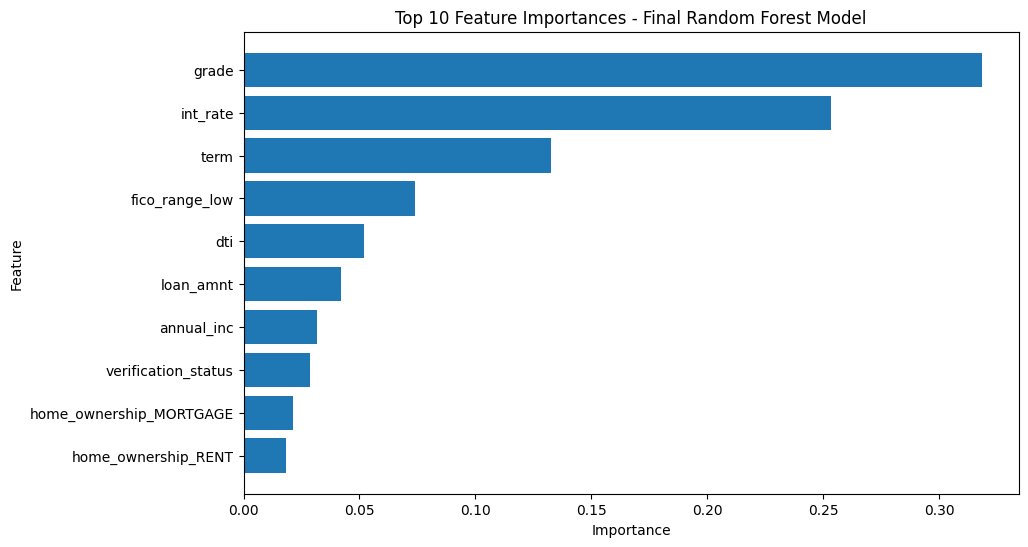

In [56]:
plt.figure(figsize=(10, 6))
plt.barh(feature_df["Feature"], feature_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Final Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 10. Final Model Comparison

The models were compared using 5-fold Stratified Cross-Validation.

This approach is more appropriate for this smaller local dataset because every observation gets used for both training and testing across different folds.

The model ranking is based mainly on recall for charged-off loans, because identifying risky loans is the main goal of this credit risk project.

In [57]:
results_percent

,Model,Accuracy Mean,Accuracy Std,Precision Defaults Mean,Precision Defaults Std,Recall Defaults Mean,Recall Defaults Std,F1 Defaults Mean,F1 Defaults Std
2,Random Forest,63.82,0.12,30.67,0.04,67.64,0.36,42.21,0.07
1,Decision Tree,63.69,1.01,30.35,0.34,66.27,2.07,41.62,0.13
3,Extra Trees,64.60,0.12,30.79,0.08,65.11,0.31,41.81,0.11
0,Logistic Regression,65.93,0.12,31.55,0.11,63.64,0.22,42.18,0.14
6,Naive Bayes,71.84,1.40,34.10,0.85,46.97,4.03,39.40,0.88
5,KNN,77.84,0.09,35.70,0.40,16.83,0.29,22.87,0.32
4,Gradient Boosting,80.69,0.04,54.96,1.09,6.32,0.18,11.34,0.28


## 11. Conclusion

This notebook tested several machine learning models to predict loan default risk.

Instead of using a single 80/20 train-test split, the project used 5-fold Stratified Cross-Validation. This makes the evaluation more reliable for a smaller dataset because the model is tested across multiple folds.

The models tested were:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Extra Trees
5. Gradient Boosting
6. XGBoost
7. KNN
8. Naive Bayes

The final comparison focused on:

- Accuracy
- Precision for charged-off loans
- Recall for charged-off loans
- F1-score for charged-off loans

For this project, recall is especially important because the goal is to identify loans that are more likely to become charged off.

The final Random Forest model was also used to identify the most important features influencing loan default risk.